In [1]:
!git clone https://github.com/EnergyBasedFlowClassifier/EFC-package.git
%cd EFC-package
!pip install -r requirements.txt
!pip install --no-build-isolation .
%cd /content/EFC-package
!python setup.py build_ext --inplace
!pip install --no-build-isolation -e .

from google.colab import drive
import os
drive.mount("/content/drive", force_remount = True)
path = "/content/drive/My Drive/TCC/Dataset-final"
if os.path.isdir(path):
  !ls "{path}"
%cd /content/
!pip install optuna

fatal: destination path 'EFC-package' already exists and is not an empty directory.
/content/EFC-package
Processing /content/EFC-package
  Preparing metadata (setup.py) ... done
  Created wheel for efc: filename=efc-0.1.0-cp312-cp312-linux_x86_64.whl size=544839 sha256=ee5eed7fdafe8b1da54cded9f05068b0e9454f06e323eb3e6253c249e12c8248
  Stored in directory: /root/.cache/pip/wheels/0d/56/b5/f8eb339887b622e9f026bccb9233add8bf358199a752a51d2a
Successfully built efc
  Attempting uninstall: efc
    Found existing installation: efc 0.1.0
    Uninstalling efc-0.1.0:
      Successfully uninstalled efc-0.1.0
/content/EFC-package
/usr/local/lib/python3.12/dist-packages/setuptools/dist.py:491: SetuptoolsDeprecationWarning: Invalid dash-separated options
!!

        ********************************************************************************
        Usage of dash-separated 'description-file' will not be supported in future
        versions. Please use the underscore name 'description_file' inste

In [2]:
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from optuna.samplers import NSGAIISampler
import matplotlib.patches as mpatches
from joblib import parallel_backend
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import optuna


from efc import EnergyBasedFlowClassifier

In [3]:
path_train = "/content/drive/My Drive/TCC/Dataset-final"
# Carrego o meu dataset balanceado
balanced_df_atack_category = pd.read_csv(f"{path_train}/balanced_df_atack_category.csv")

# Defino oq é saída e oq é entrada
X = balanced_df_atack_category.select_dtypes(include = np.number)
y = balanced_df_atack_category['Label']

# Divisão em teste e treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

# Codificação dos rótulos
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [4]:
balanced_df_atack_category

,Header_Length,Protocol_Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot_sum,Min,Max,AVG,Std,Tot_size,IAT,Number,Variance,Label
0,0.00,1,64.00,80120.420248,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000013,100,0.000000,DDoS
1,8.00,17,64.00,76454.684652,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000013,100,0.000000,DDoS
2,0.00,1,64.00,20488.003126,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000049,100,0.000000,DoS
3,29.96,6,113.03,35.137120,0.0,0.0,0.0,0.30,0.93,0.0,...,10004,60,827,100.04,113.939459,100.04,0.029393,100,12982.200404,Benign
4,28.72,6,61.33,16.788267,0.0,0.0,0.0,0.41,0.89,0.0,...,8719,42,928,87.19,89.146196,87.19,0.059565,100,7947.044343,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,8.00,17,64.00,112.115090,0.0,0.0,0.0,0.00,0.00,0.0,...,2676,102,1226,267.60,342.840488,267.60,0.009197,10,117539.600000,Spoofing
47996,20.00,6,64.00,16028.370529,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000062,100,0.000000,DoS
47997,0.00,1,64.00,57080.892760,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000018,100,0.000000,DDoS
47998,30.32,6,64.02,16.674676,0.0,0.0,0.0,0.47,0.93,0.0,...,9631,66,929,96.31,91.910551,96.31,0.059971,100,8447.549394,Benign


In [5]:
balanced_df_atack_category['Label'].value_counts()

,count
Label,
DDoS,8000
DoS,8000
Benign,8000
MQTT_Attack,8000
Spoofing,8000
Reconnaissance,8000


In [6]:
def objective(trial):
  param_n_bins = trial.suggest_int('n_bins', 10, 100)
  param_cutoff = trial.suggest_float('cutoff_quantile', 0.75, 0.99)
  param_pseudocounts = trial.suggest_float('pseudocounts', 0.2, 0.8)

  model = EnergyBasedFlowClassifier(
      n_bins = param_n_bins,
      cutoff_quantile = param_cutoff,
      pseudocounts = param_pseudocounts,
      n_jobs = 1
  )

  score = cross_val_score(
      model,
      X_train,
      y_train_encoded,
      n_jobs = 1,
      cv = 3,
      scoring = 'f1_weighted'
  )

  return score.mean()

In [7]:
n = 50

tpe = optuna.create_study(direction = "maximize") # Algoritmo de otimização bayesiana
tpe.optimize(
    objective,
    n_trials = n,
    show_progress_bar = True
)

sampler_ga = NSGAIISampler(population_size = 10, seed = 42)
ga = optuna.create_study(direction = "maximize", sampler = sampler_ga)
ga.optimize(
    objective,
    n_trials = n,
    show_progress_bar = True
)

print("\n--- TPE ---")
print(f"Melhor F1-Score (fitness): {tpe.best_value:.6f}")
print(f"Melhores 'Genes' (parâmetros): {tpe.best_params}")

print("\n--- GA---")
print(f"Melhor F1-Score (fitness): {ga.best_value:.6f}")
print(f"Melhores 'Genes' (parâmetros): {ga.best_params}")


[I 2026-05-07 17:01:28,682] A new study created in memory with name: no-name-3d6e4a8d-743b-4d53-8dbf-5dfbec3c1a71


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-07 17:03:08,080] Trial 0 finished with value: 0.7831636279432826 and parameters: {'n_bins': 80, 'cutoff_quantile': 0.8350184708458769, 'pseudocounts': 0.21695698602345448}. Best is trial 0 with value: 0.7831636279432826.
[I 2026-05-07 17:03:48,238] Trial 1 finished with value: 0.853164999481599 and parameters: {'n_bins': 49, 'cutoff_quantile': 0.8835960005070658, 'pseudocounts': 0.42973868258849945}. Best is trial 1 with value: 0.853164999481599.
[I 2026-05-07 17:05:06,885] Trial 2 finished with value: 0.8487689506987167 and parameters: {'n_bins': 74, 'cutoff_quantile': 0.8855335123949878, 'pseudocounts': 0.48856423506315627}. Best is trial 1 with value: 0.853164999481599.
[I 2026-05-07 17:05:27,883] Trial 3 finished with value: 0.857377888932998 and parameters: {'n_bins': 28, 'cutoff_quantile': 0.9112008837196127, 'pseudocounts': 0.4006690109618772}. Best is trial 3 with value: 0.857377888932998.
[I 2026-05-07 17:06:45,754] Trial 4 finished with value: 0.787454475027856 and

[I 2026-05-07 17:27:23,279] A new study created in memory with name: no-name-69ee7a61-3b30-4867-b54b-331c27f3bc0a


[I 2026-05-07 17:27:23,273] Trial 49 finished with value: 0.8781335323688727 and parameters: {'n_bins': 41, 'cutoff_quantile': 0.7611028096578979, 'pseudocounts': 0.7373226019438307}. Best is trial 18 with value: 0.8925312881168678.


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-07 17:27:55,854] Trial 0 finished with value: 0.8627220212584202 and parameters: {'n_bins': 44, 'cutoff_quantile': 0.9781714335383799, 'pseudocounts': 0.6391963650868431}. Best is trial 0 with value: 0.8627220212584202.
[I 2026-05-07 17:28:57,028] Trial 1 finished with value: 0.8008803778968246 and parameters: {'n_bins': 64, 'cutoff_quantile': 0.7874444737061848, 'pseudocounts': 0.2935967122017216}. Best is trial 0 with value: 0.8627220212584202.
[I 2026-05-07 17:29:09,463] Trial 2 finished with value: 0.8882044302196778 and parameters: {'n_bins': 15, 'cutoff_quantile': 0.9578822749859844, 'pseudocounts': 0.5606690070459254}. Best is trial 2 with value: 0.8882044302196778.
[I 2026-05-07 17:30:29,065] Trial 3 finished with value: 0.8623034432154331 and parameters: {'n_bins': 74, 'cutoff_quantile': 0.7549402786309926, 'pseudocounts': 0.7819459112971967}. Best is trial 2 with value: 0.8882044302196778.
[I 2026-05-07 17:32:02,553] Trial 4 finished with value: 0.8007148723929388 

In [15]:
EFC_TPE = EnergyBasedFlowClassifier(
    n_bins = 18,
    cutoff_quantile = 0.7668761175517792,
    pseudocounts = 0.5549765516061752,
    n_jobs = 1
)

EFC_TPE.fit(X_train, y_train_encoded)
y_pred_TPE = EFC_TPE.predict(X_test)
print("\n--- Relatório de Avaliação (EFC TPE) ---\n")
print(classification_report(y_test_encoded, y_pred_TPE, target_names = le.classes_))


--- Relatório de Avaliação (EFC TPE) ---

                precision    recall  f1-score   support

        Benign       0.97      0.96      0.97      1600
          DDoS       0.93      0.66      0.77      1600
           DoS       0.73      0.93      0.82      1600
   MQTT_Attack       0.97      0.97      0.97      1600
Reconnaissance       1.00      0.91      0.95      1600
      Spoofing       0.89      0.99      0.94      1600

      accuracy                           0.90      9600
     macro avg       0.91      0.90      0.90      9600
  weighted avg       0.91      0.90      0.90      9600



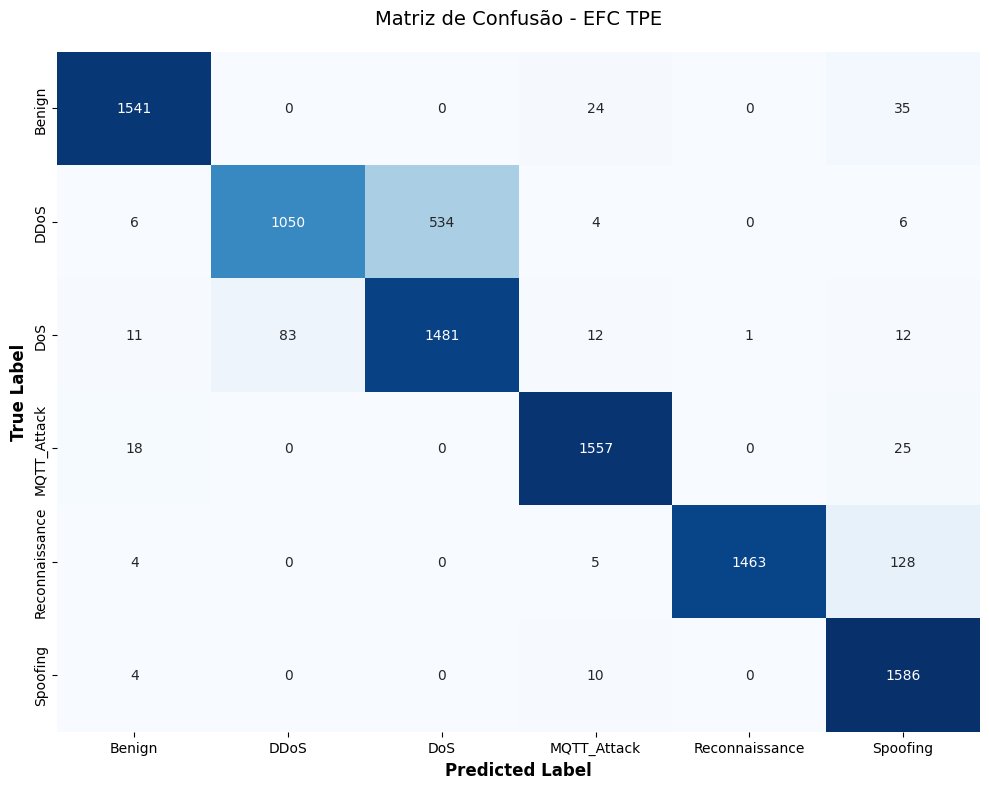

In [16]:
cm = confusion_matrix(y_test_encoded, y_pred_TPE)
class_names = le.classes_
plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = class_names,
            yticklabels = class_names,
            cbar = False)

plt.title("Matriz de Confusão - EFC TPE", fontsize = 14, pad = 20)
plt.ylabel('True Label', fontsize = 12, fontweight = 'bold')
plt.xlabel('Predicted Label', fontsize = 12, fontweight ='bold')
plt.tight_layout()
plt.show()


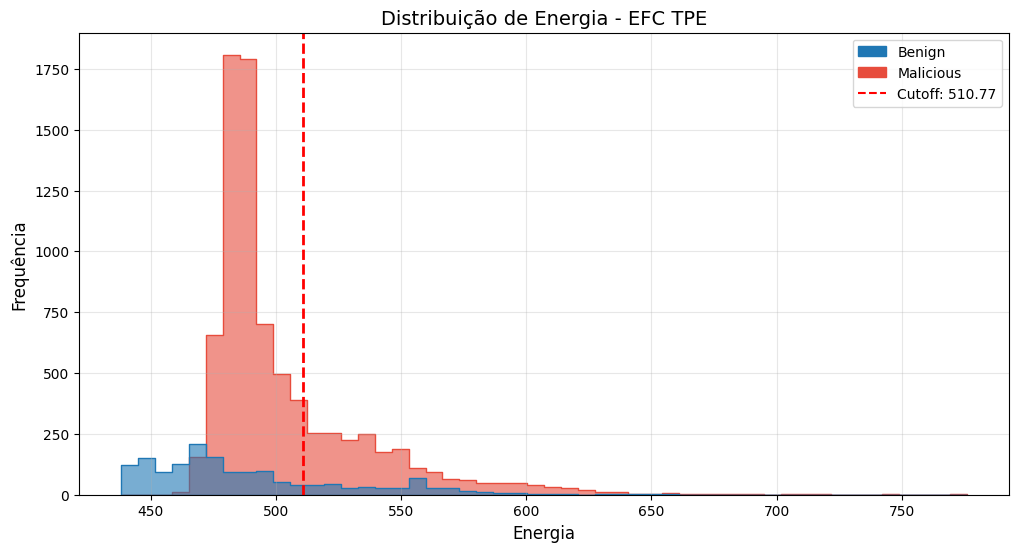

In [17]:
_, energies_tpe = EFC_TPE.predict(X_test, return_energies = True)

df_viz_tpe = pd.DataFrame()
df_viz_tpe['Energy'] = energies_tpe
df_viz_tpe['Label'] = le.inverse_transform(y_test_encoded)
df_viz_tpe['Tipo'] = df_viz_tpe['Label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Malicious')

idx_benign = le.transform(['Benign'])[0]
cutoff_tpe = EFC_TPE.estimators_[idx_benign].cutoff_
plt.figure(figsize=(12, 6))

sns.histplot(data = df_viz_tpe, x = "Energy", hue = "Tipo",
             element = "step", fill = True, stat = "count",
             bins = 50, alpha = 0.6,
             palette = {"Benign": "#1f77b4", "Malicious": "#E74C3C"},
             legend = False)

plt.axvline(cutoff_tpe, color = 'red', linestyle = '--', linewidth = 2)

patch_normal = mpatches.Patch(color = "#1f77b4", label = 'Benign')
patch_ataque = mpatches.Patch(color = "#E74C3C", label = 'Malicious')
linha_cutoff = mlines.Line2D([], [], color = 'red', linestyle = '--',
                             label = f'Cutoff: {cutoff_tpe:.2f}')

plt.legend(handles=[patch_normal, patch_ataque, linha_cutoff], loc = 'upper right')

plt.title(f"Distribuição de Energia - EFC TPE", fontsize = 14)
plt.xlabel("Energia", fontsize = 12)
plt.ylabel("Frequência", fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

In [24]:
EFC_GA = EnergyBasedFlowClassifier(
    n_bins = 15,
    cutoff_quantile = 0.7608545493385291,
    pseudocounts = 0.5148538589793428,
    n_jobs = 1
)

EFC_GA.fit(X_train, y_train_encoded)
y_pred_GA = EFC_GA.predict(X_test)
print("\n--- Relatório de Avaliação (EFC GA) ---\n")
print(classification_report(y_test_encoded, y_pred_GA, target_names=le.classes_))


--- Relatório de Avaliação (EFC GA) ---

                precision    recall  f1-score   support

        Benign       0.97      0.95      0.96      1600
          DDoS       0.93      0.62      0.74      1600
           DoS       0.72      0.93      0.81      1600
   MQTT_Attack       0.97      0.98      0.97      1600
Reconnaissance       1.00      0.90      0.95      1600
      Spoofing       0.86      0.98      0.92      1600

      accuracy                           0.89      9600
     macro avg       0.91      0.89      0.89      9600
  weighted avg       0.91      0.89      0.89      9600



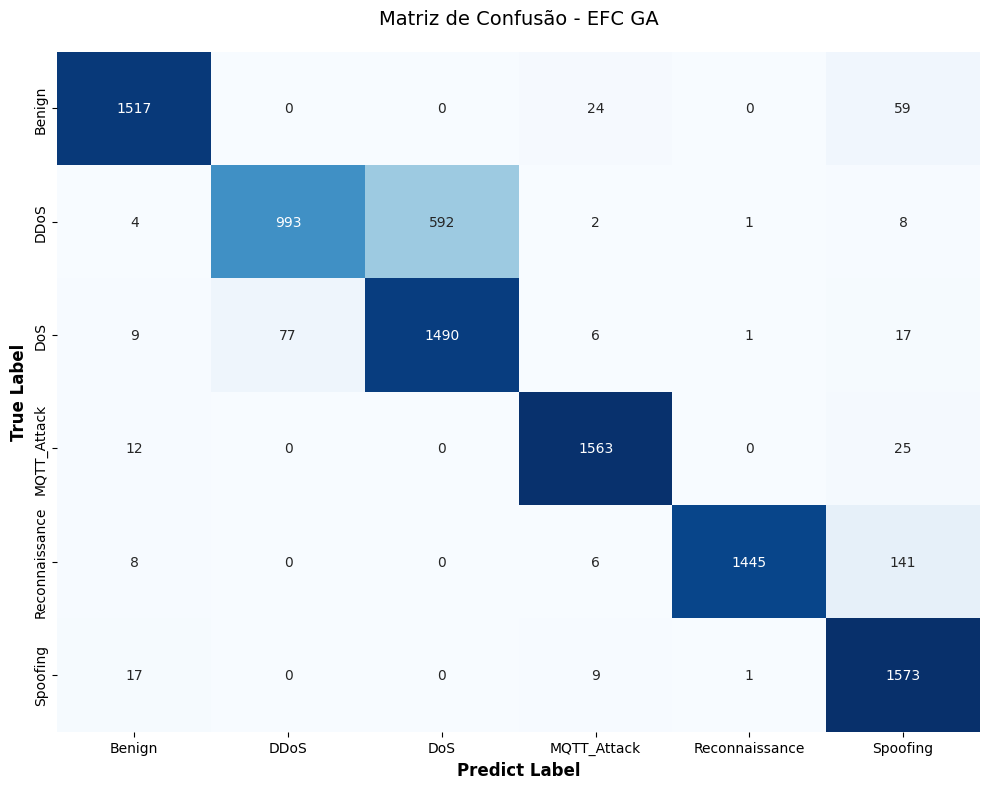

In [20]:
cm_ga = confusion_matrix(y_test_encoded, y_pred_GA)
classes_labels = le.classes_

plt.figure(figsize = (10, 8))
sns.heatmap(cm_ga, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = classes_labels,
            yticklabels = classes_labels,
            cbar = False)

plt.title("Matriz de Confusão - EFC GA", fontsize = 14, pad = 20)
plt.ylabel('True Label', fontsize = 12, fontweight = 'bold')
plt.xlabel('Predict Label', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

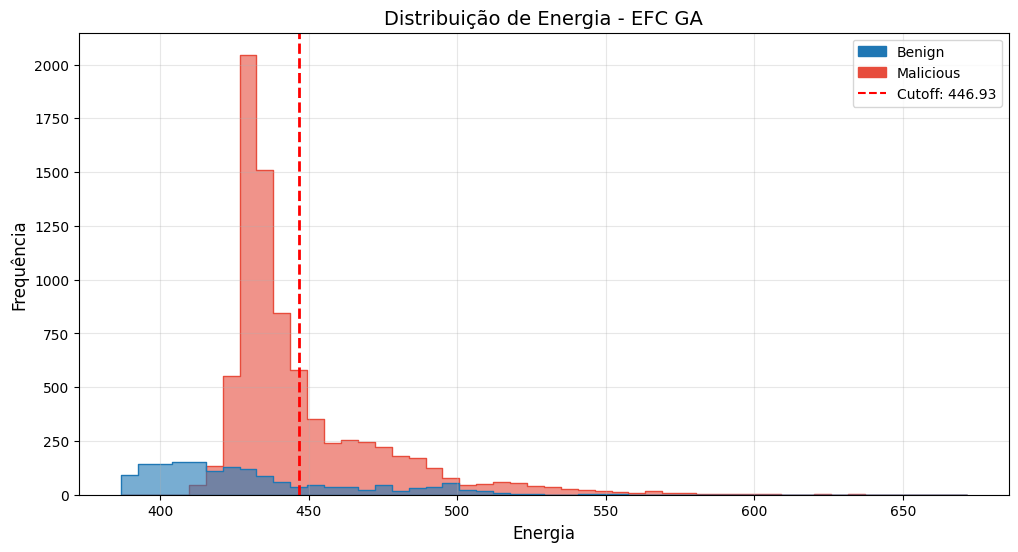

In [21]:
_, energies_ga = EFC_GA.predict(X_test, return_energies=True)

df_viz_ga = pd.DataFrame()
df_viz_ga['Energy'] = energies_ga
df_viz_ga['Label'] = le.inverse_transform(y_test_encoded)
df_viz_ga['Tipo'] = df_viz_ga['Label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Malicious')

idx_benign = le.transform(['Benign'])[0]
cutoff_ga = EFC_GA.estimators_[idx_benign].cutoff_
plt.figure(figsize=(12, 6))
sns.histplot(data=df_viz_ga, x = "Energy", hue = "Tipo",
             element = "step", fill = True, stat = "count",
             bins = 50, alpha = 0.6,
             palette={"Benign": "#1f77b4", "Malicious": "#E74C3C"},
             legend=False)

plt.axvline(cutoff_ga, color = 'red', linestyle = '--', linewidth = 2)
patch_normal = mpatches.Patch(color = "#1f77b4", label = 'Benign')
patch_ataque = mpatches.Patch(color = "#E74C3C", label = 'Malicious')
linha_cutoff = mlines.Line2D([], [], color = 'red', linestyle = '--',
                             label=f'Cutoff: {cutoff_ga:.2f}')

plt.legend(handles = [patch_normal, patch_ataque, linha_cutoff], loc = 'upper right')

plt.title(f"Distribuição de Energia - EFC GA", fontsize=14)
plt.xlabel("Energia", fontsize = 12)
plt.ylabel("Frequência", fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

## Gráfico mágico

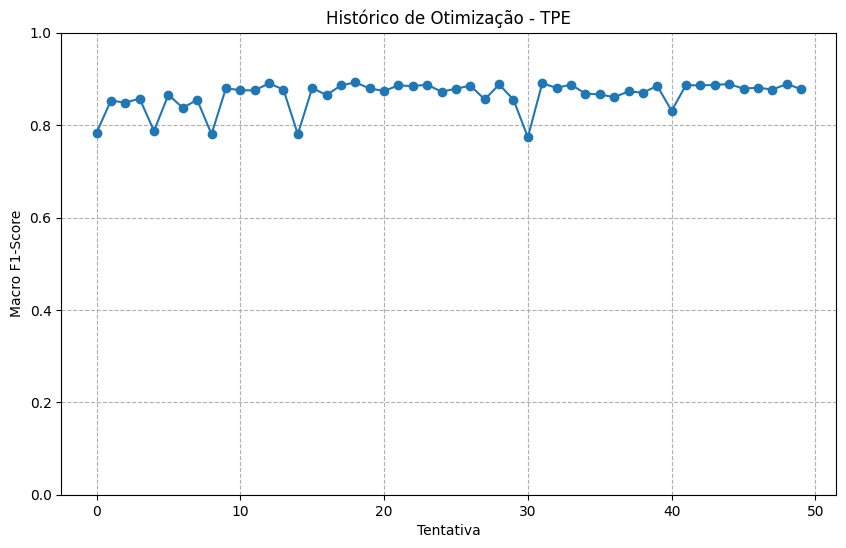

In [32]:
df_tpe = tpe.trials_dataframe()
plt.figure(figsize=(10, 6))
plt.plot(df_tpe['number'], df_tpe['value'], color='tab:blue', marker='o')
plt.title('Histórico de Otimização - TPE')
plt.xlabel('Tentativa')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1)
plt.grid(True, linestyle='--')
plt.savefig('hist_tpe.png', dpi=300)
plt.show()

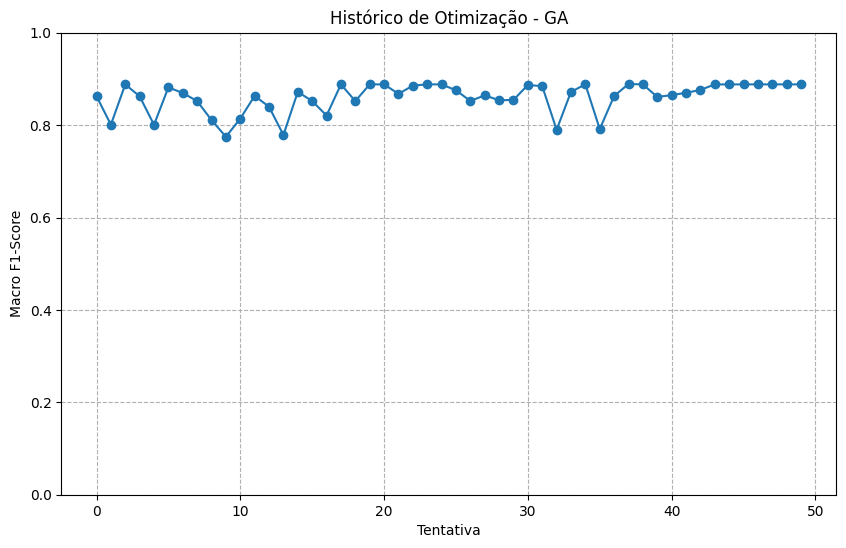

In [33]:
import matplotlib.pyplot as plt

df_ga = ga.trials_dataframe()
plt.figure(figsize=(10, 6))
plt.plot(df_ga['number'], df_ga['value'], color='tab:blue', marker='o')
plt.title('Histórico de Otimização - GA')
plt.xlabel('Tentativa')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1)
plt.grid(True, linestyle='--')
plt.savefig('hist_ga.png', dpi=300)
plt.show()

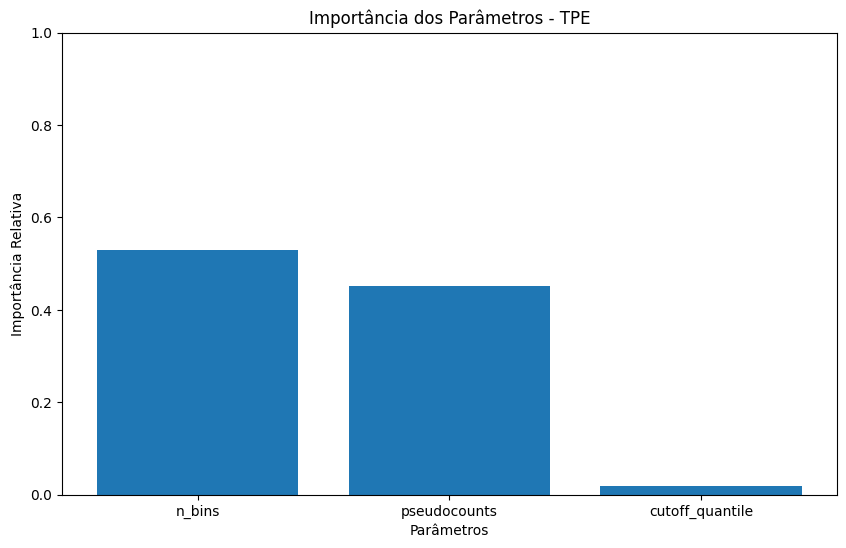

In [34]:
imp_tpe = optuna.importance.get_param_importances(tpe)
plt.figure(figsize=(10, 6))
plt.bar(imp_tpe.keys(), imp_tpe.values(), color='tab:blue')
plt.title('Importância dos Parâmetros - TPE')
plt.xlabel('Parâmetros')
plt.ylabel('Importância Relativa')
plt.ylim(0, 1)
plt.savefig('importancia_tpe.png', dpi=300)
plt.show()

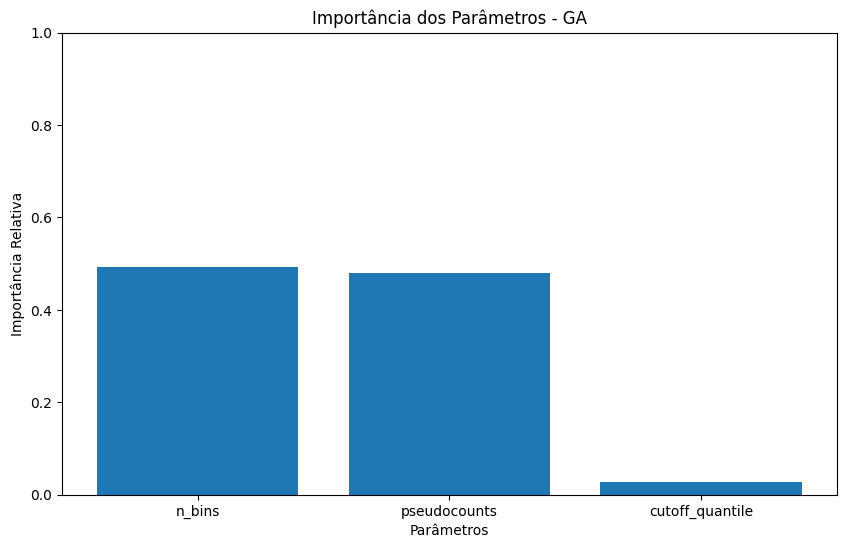

In [35]:
import matplotlib.pyplot as plt
import optuna

imp_ga = optuna.importance.get_param_importances(ga)
plt.figure(figsize=(10, 6))
plt.bar(imp_ga.keys(), imp_ga.values(), color='tab:blue')
plt.title('Importância dos Parâmetros - GA')
plt.xlabel('Parâmetros')
plt.ylabel('Importância Relativa')
plt.ylim(0, 1)
plt.savefig('importancia_ga.png', dpi=300)
plt.show()

In [36]:
import optuna.visualization as vis

# Compara o progresso dos dois estudos no tempo
fig_hist = vis.plot_optimization_history([tpe, ga])
fig_hist.show()

# Exibe a curva de probabilidade de sucesso dos métodos
fig_edf = vis.plot_edf([tpe, ga])
fig_edf.show()

# Avalia quais parâmetros afetaram mais o resultado do TPE
fig_imp_tpe = vis.plot_param_importances(tpe)
fig_imp_tpe.show()

# Avalia quais parâmetros afetaram mais o resultado do GA
fig_imp_ga = vis.plot_param_importances(ga)
fig_imp_ga.show()